## Exercise Project 1 

Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

Shape: `34k rows, 19 columns`

Target Variable: `sale_price`

Method: `Linear Regression`

Extra Tools: `Mlflow`



---

### Code

In [206]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from skfeature.function.similarity_based import fisher_score
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.preprocessing import OneHotEncoder
import mlflow
import mlflow.sklearn

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1| <bold style="background:yellow;color:black;">Data Cleaning </bold>|
|2| Feature Engineering|
|3| ML Implementation|
|4| Model Application|


#### Checking Shape

In [207]:
# Checking the amount of columns and rows.
df.shape

# That seems like a reasonable amount of data. Lots to work with.

(34439, 19)

#### Missing Values

In [208]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. 

# Dropping nan values.
df = df.dropna()

##### Dropping Columns

In [209]:
# Filtering out any rows which may be for commercial uses.
df[df['comarea'] > 0].shape

# Dropping columns that initially can be seen as redundant or irrelevant
df = df.drop(["borough_x", "block", "lot",'latitude','longitude'], axis=1)



### Selecting Features

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Feature Engineering</bold>|
|3| ML Implementation|
|4| Model Application|

Correlation Matrix


28810


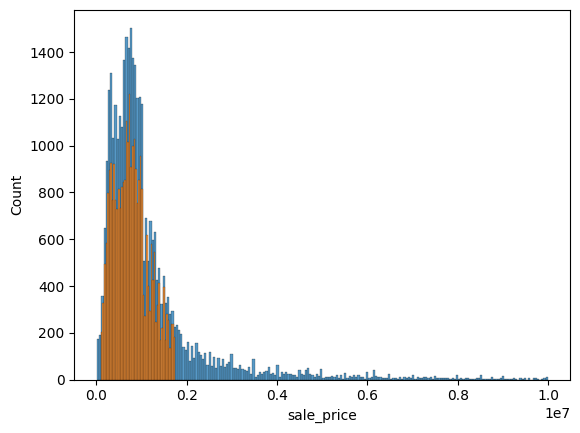

In [210]:
# Target variable cutoffs.
y_trunc_floor = 0.01
y_trunc_ceiling = 0.85

# First, we create a histplot of the target variable's -- We're checking the distribution.
sns.histplot(df, x='sale_price')

# Our target variable is EXTREMELY skewed.

# Second, alliviate some of the skewing via truncating the data.
# I like to use a multi-filtering approach for readability.
df = df[
    (df['sale_price'] >= df['sale_price'].quantile(q=y_trunc_floor)) &
    (df['sale_price'] <= df['sale_price'].quantile(q=y_trunc_ceiling))
    ]

# Finally, plot over the previous distribution.
sns.histplot(df, x='sale_price')

# RESULTS:
# Not great. But it's probably the best we can get.
# We'll have to wait until Tuomas can give some pointers.

# SANITY CHECK:
# Let's check how many rows we have left.
print(df.shape[0])

Continuous Column Correlation Matrix

<Axes: >

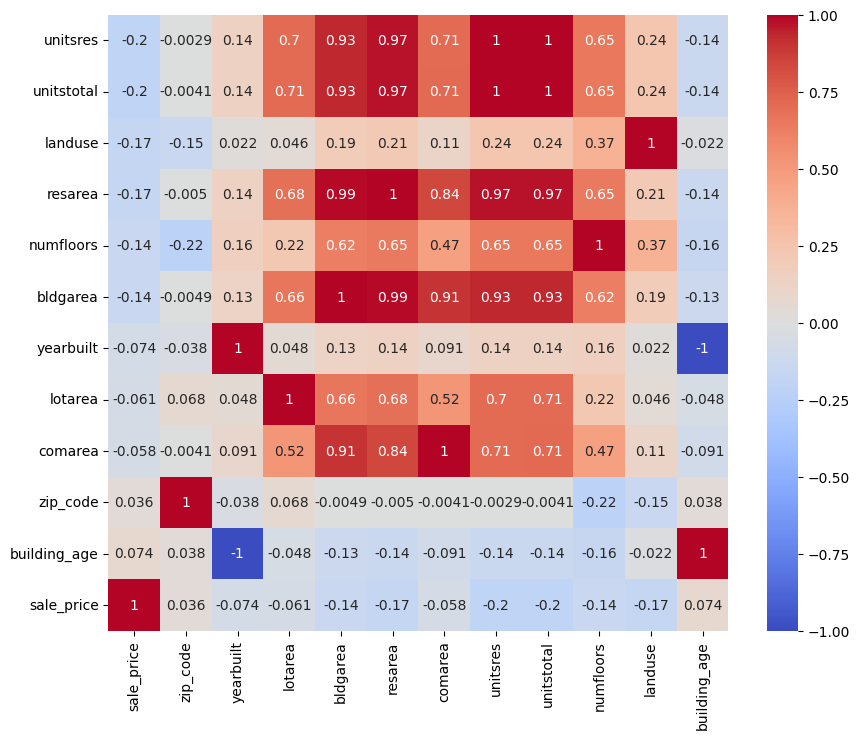

In [211]:
# Pearson correlation heatmap (matrix)
correlations = df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm')

# df = df[['sale_price', 'resarea', 'bldgarea','unitsres','unitstotal','numfloors', 'landuse','borough_y','bldgclass']]


#### 

Changing Categorical Columns to Numbers

In [212]:
# This converts two categorical features into separate binary columns.

# NOTE: this will create a ton of columns, an that's ok! We'll let the
# colors do the talking.
categorical_columns = ["borough_y","bldgclass"]

for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)


FULL Correlation Matrix (With categorical columns)

<Axes: >

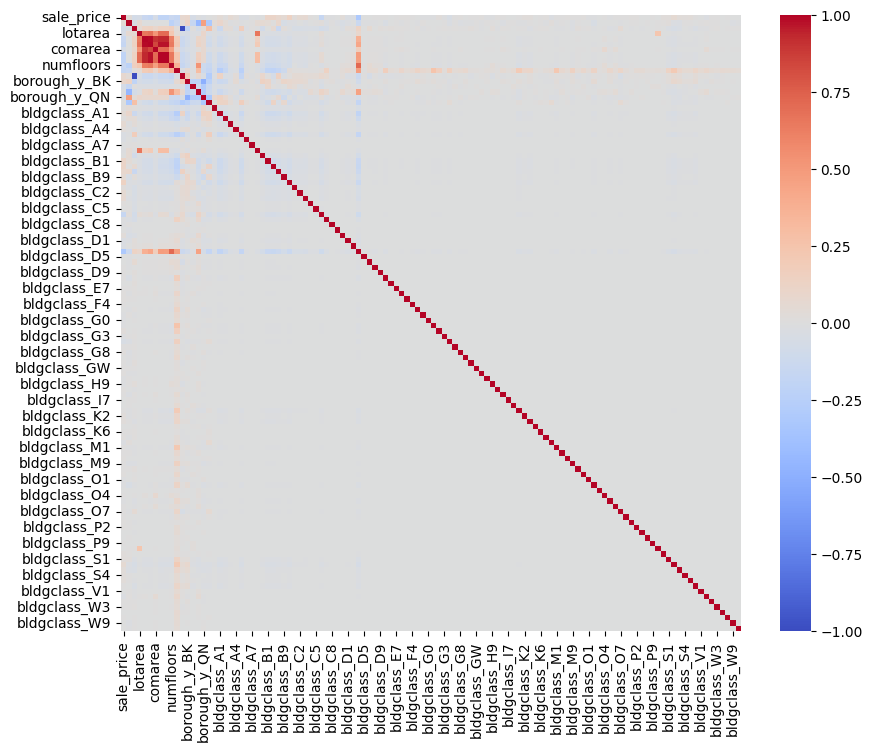

In [ ]:
# METHOD 1: CORRELATION HEATMAP
correlations = df.corr(method= "pearson", numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(correlations, cmap='coolwarm')

# Two observations:
# bldgclass_D4 appears to correlate with sale_price.
# We can't really see the borough results well, it needs to be looked at closer.


<Axes: >

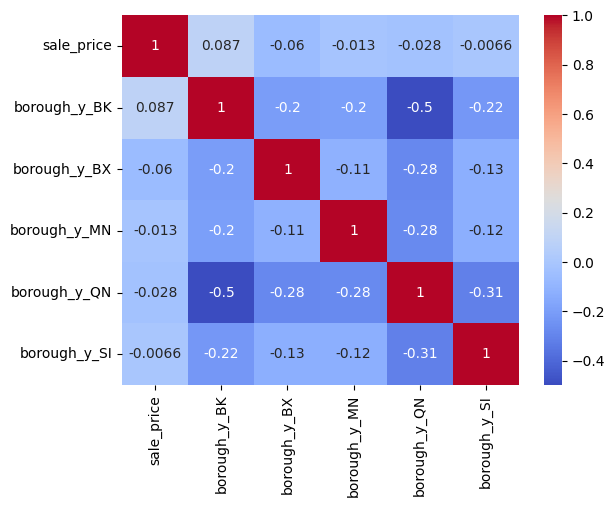

In [214]:
# Let's create a dataframe with only the boroughs so we can look at them
# more closel.y

# Filtering
df_bclass = df[['sale_price',
         'borough_y_BK',
         'borough_y_BX',
         'borough_y_MN',
         'borough_y_QN',
         'borough_y_SI'
           ]]


# Heatmap
correlations = df_bclass.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, cmap='coolwarm')

# Looks like boroughs are not a great predictor to sale_price. Shame!

<Axes: >

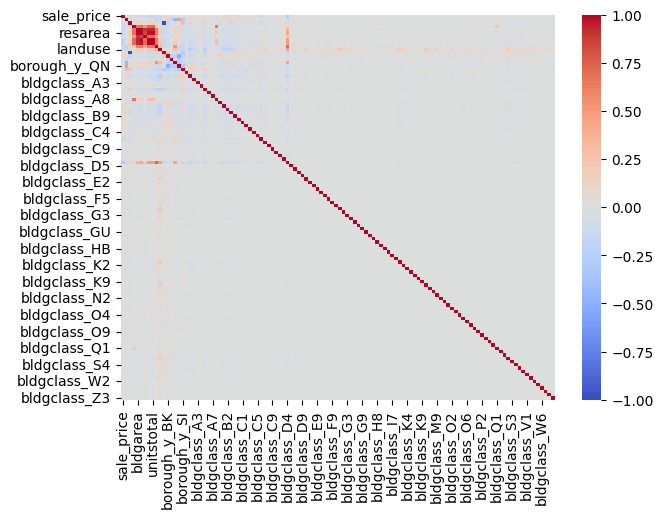

In [215]:
# METHOD 1: CORRELATION HEATMAP
correlations = df.corr( numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(correlations, cmap='coolwarm')

# bldgclass_D4 correlates with sales price.

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| Feature Engineering|
|3| <bold style="background:yellow;color:black;">ML Implementation</bold>|
|4| Model Application|


#### Linear Regression Model Creation

In [216]:
# Constants
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df.drop("sale_price", axis=1)
y = df['sale_price']

# Normalize the features (between zero and one!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test-split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=XY_SPLIT, random_state=101)

# Initializes the experiment in MLFLOW.
mlflow.set_experiment("ex1_project_a")

with mlflow.start_run():
    # Initalization
    lm = LinearRegression()
    lm.fit(X_train, y_train)

    # Find the intercept value of the regression
    intercept = lm.intercept_

    # Create a list of coefficients for each feature.
    coefs = lm.coef_
    print(coefs)

    # Predict the data with the model.
    predictions = lm.predict(X_test)

    # -- METRICS RECORDING -- 
    mae = metrics.mean_absolute_error(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
    r_sq = metrics.r2_score(y_test, predictions)

    # -- MLFLOW LOGGING --
    mlflow.set_tag("dataset", "kaggle_house_prices_v1")
    mlflow.set_tag("data_split", str(XY_SPLIT))
    mlflow.log_param("exercise_project_name","ex1_a")
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("y_variable_truncation_amt", f"{y_trunc_floor, y_trunc_ceiling}")
    mlflow.log_param("features", str(X.columns))
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r_squared", r_sq)
    mlflow.sklearn.log_model(lm, "model")



2026/01/20 21:23:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[ 4.06324268e+04  7.87565964e+02  4.30977468e+04  6.16354326e+06
 -4.55608331e+06 -1.66102347e+06 -1.41074848e+06  1.18821448e+06
  7.50421281e+04 -4.61115562e+04 -7.87565963e+02 -3.24486549e+01
 -2.93715116e+04  8.20001121e+04 -2.06669666e+04 -1.64346434e+04
  6.09155089e+03  1.44364888e+04  5.07664382e+03  2.35788884e+04
  7.66409025e+03 -5.53528078e+03 -9.64329016e+03  1.69649781e+03
 -1.14672035e+04 -4.59611426e+03  3.66272176e+04  4.11171379e+04
  2.72525080e+04  2.22090396e+04  5.84160930e+04  7.33112282e+03
  2.53565939e+04  2.95903083e+04  5.98241208e+02 -3.77951493e+03
 -6.85829194e+04 -7.18624084e+03 -6.09316015e+03  2.55674399e+03
  8.07359981e+01 -1.06420039e+04 -1.42287031e+04 -1.36887440e+05
 -2.76519022e+03 -4.42191272e+03  1.67491551e+03 -2.07596448e+03
  1.00545388e+04  1.31789450e+03  5.85093354e+03  4.68923699e+03
  6.01182321e+03  5.57097345e+03  5.04516306e+03  2.79723784e+03
 -1.18626629e+03  5.68839394e+03  1.43420081e+04 -2.33039988e+03
 -7.28277363e+03  2.34009

#### Metrics & Parameters

In [217]:
# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("Features Used:")
print(f"{list(X.columns)} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}")



METRICS
--------------------------
MAE
261314.73 

MSE
125161957608.49 

RMSE
353782.36 

R-squared:
0.17 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.85) 

Features Used:
['zip_code', 'yearbuilt', 'lotarea', 'bldgarea', 'resarea', 'comarea', 'unitsres', 'unitstotal', 'numfloors', 'landuse', 'building_age', 'borough_y_BK', 'borough_y_BX', 'borough_y_MN', 'borough_y_QN', 'borough_y_SI', 'bldgclass_A0', 'bldgclass_A1', 'bldgclass_A2', 'bldgclass_A3', 'bldgclass_A4', 'bldgclass_A5', 'bldgclass_A6', 'bldgclass_A7', 'bldgclass_A8', 'bldgclass_A9', 'bldgclass_B1', 'bldgclass_B2', 'bldgclass_B3', 'bldgclass_B9', 'bldgclass_C0', 'bldgclass_C1', 'bldgclass_C2', 'bldgclass_C3', 'bldgclass_C4', 'bldgclass_C5', 'bldgclass_C6', 'bldgclass_C7', 'bldgclass_C8', 'bldgclass_C9', 'bldgclass_D0', 'bldgclass_D1', 'bldgclass_D3', 'bldgclass_D4', 'bldgclass_D5', 'bldgclass_D6', 'bldgclass_D7', 'bldgclass_D9', 'bldgclass_E1', 'bldgclass_E2', 'bldgclass_E7', 'bldgclass_E

#### Scatterplot Linearity Test

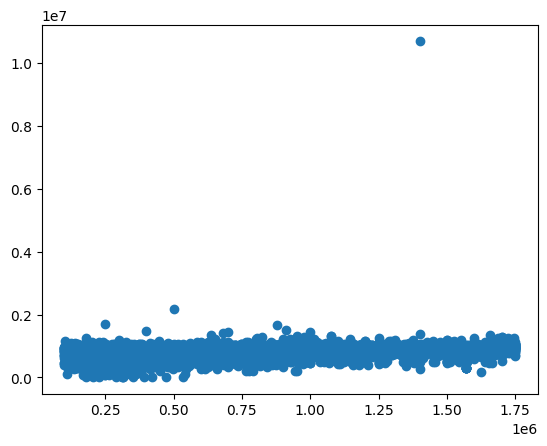

In [218]:
# If these values follow a line = good predictions
plt.scatter(y_test, predictions)
plt.show()

---

#### Model Application

|Step|Description|
|---|---|
|1|Data Cleaning|
|2| Feature Engineering|
|3| ML Implementation|
|4|<bold style="background:yellow;color:black;"> Model Application</bold>|